[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/Alternative_Role_Classifier_Analyzer.ipynb)

**📝 Before using:** Update the GitHub URL above with your actual username and repository name.

## 2. File Upload and Data Loading

In [1]:
# =========================================================================
#  NEW  ☢ STEP 1: CHOOSE YOUR MODEL MODE
# =========================================================================
# Options: 'CLAUDE_API', 'GEMINI_API', 'HUGGINGFACE_API', 'TASK_COUNCIL'
MODEL_MODE = 'TASK_COUNCIL'

# If using TASK_COUNCIL, define the pair:
PRIMARY_MODEL = "claude-sonnet-4-5-20250929"
VALIDATOR_MODEL = "deepseek-ai/DeepSeek-R1-Distill-Llama-70B"

# General Settings
TEMPERATURE = 0.0  # Kept at 0.0 for maximum consistency in classification
MAX_TOKENS = 4096

In [2]:
# =========================================================================
# ☥ STEP 2: API Keys & General Configuration
# =========================================================================

import os
import json
import zipfile
import pandas as pd
from tqdm.auto import tqdm
from google.colab import files, userdata

# API Keys (Set via Colab Secrets ☥ or manually here)
ANTHROPIC_API_KEY = ""
GEMINI_API_KEY = ""
MISTRAL_API_KEY = "" # <<< ADD MISTRAL API KEY HERE >>>
HF_TOKEN = userdata.get('LLamaCoLab') # Retrieve the user's Hugging Face token from secrets

# General Settings
ZIP_FILE_PATH = "/content/Evaluation Resources.zip"
OUTPUT_PATH = "/content/analysis_results"
MAX_TOKENS = 4096
TEMPERATURE = 0.1

# -------------------------------------------------------------------------
# MISTRAL CONFIGURATION
# -------------------------------------------------------------------------
MISTRAL_MODEL_NAME = "mistral-large-latest" # or "mistral-small-latest", "open-mistral-nemo"

# -------------------------------------------------------------------------
# HUGGING FACE API CONFIGURATION
# -------------------------------------------------------------------------
#HF_MODEL_ID = "tiiuae/falcon-180B-chat"
HF_MODEL_ID = "Qwen/Qwen2.5-72B-Instruct"

# OTHER CONFIGS (Do not change)
#CLAUDE_MODEL_NAME = "claude-sonnet-4-20250514"
#CLAUDE_MODEL_NAME = "claude-sonnet-4-20250514"
# CLAUDE_MODEL_NAME = "claude-opus-4-1-20250805" # Claude Opus 4.1
CLAUDE_MODEL_NAME = "claude-sonnet-4-5-20250929"  # Fallback to Sonnet 4.5 if needed
GEMINI_MODEL_NAME = "gemini-2.5-pro"
#LLAMA_8B_MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"
LLAMA_70B_MODEL_NAME = "meta-llama/Llama-3.1-70B-Instruct"
USE_4BIT_QUANTIZATION = True


In [3]:
# =========================================================================
# ⟳ STEP 3: Dependency Installation and LOAD DATA FILES
# =========================================================================

# Build install command
install_command = "pip install -q pandas numpy matplotlib seaborn plotly networkx tqdm sentence-transformers"

if MODEL_MODE == 'CLAUDE_API':
    install_command += " anthropic>=0.34.0"
    try: ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
    except: pass
elif MODEL_MODE == 'GEMINI_API':
    install_command += " google-genai"
    try: GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    except: pass
elif MODEL_MODE == 'MISTRAL_API':
    install_command += " mistralai"
    try: MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')
    except: pass
elif MODEL_MODE == 'HUGGINGFACE_API':
    install_command += " huggingface_hub"
    # HF_TOKEN is already set from userdata.get('LLamaCoLab') above.
    # No need to try/except for specific names here if LLamaCoLab is the source.
    # If other HF keys are preferred for this mode, add fallback logic.
    pass
else:
    install_command += " torch torchvision torchaudio transformers accelerate bitsandbytes"

print(f"\n📦 Installing dependencies for {MODEL_MODE}...")
os.system(install_command)
print("✅ Dependencies installed.\n")
print("⬆️ Please upload 'Evaluation Resources.zip' when prompted.\n")
uploaded = files.upload()

if 'Evaluation Resources.zip' not in uploaded:
    raise FileNotFoundError("❌ 'Evaluation Resources.zip' not found. Please upload the file.")

# Extract zip file
with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content/")
print("✅ Files extracted successfully.\n")

# =========================================================================
# ƒ LOAD DATA FILES
# =========================================================================

from typing import List, Dict

def find_and_load_json(filename: str) -> List[Dict]:
    """Search for and load a JSON file from extracted contents."""
    # Prioritize direct path, as zip extraction goes to /content/
    direct_filepath = os.path.join("/content/", filename)
    if os.path.exists(direct_filepath):
        with open(direct_filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        print(f"  ✅ Loaded {filename}: {len(data)} records")
        return data

    # Fallback to os.walk if not found directly (e.g., if extracted to a subdirectory)
    for root, dirs, files_list in os.walk("/content/"):
        for file in files_list:
            if file.lower() == filename.lower():
                filepath = os.path.join(root, file)
                with open(filepath, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                print(f"  ✅ Loaded {filename}: {len(data)} records")
                return data
    print(f"  ❌ Warning: {filename} not found")
    return []

print("🔍 Loading data files...\n")

# Load all required files
sample_jds = find_and_load_json('Sample_JDs.json')
classifications = find_and_load_json('Job_Classifications_Batch.json')
ground_truth = find_and_load_json('Ground_Truth_Masterfile.json')
ksacs = find_and_load_json('MNPS_KSACs.json')
problem_roles = find_and_load_json('Problem_Role_Cheat_Sheet.json') # Corrected filename

# Store in dictionary for easy access
datasets = {
    'sample_jds': sample_jds,
    'classifications': classifications,
    'ground_truth': ground_truth,
    'ksacs': ksacs,
    'problem_roles': problem_roles
}

print(f"\n✅ Data loading complete!")


📦 Installing dependencies for TASK_COUNCIL...
✅ Dependencies installed.

⬆️ Please upload 'Evaluation Resources.zip' when prompted.



Saving Evaluation Resources.zip to Evaluation Resources.zip
✅ Files extracted successfully.

🔍 Loading data files...

  ✅ Loaded Sample_JDs.json: 43 records
  ✅ Loaded Job_Classifications_Batch.json: 43 records
  ✅ Loaded Ground_Truth_Masterfile.json: 176 records
  ✅ Loaded MNPS_KSACs.json: 315 records
  ✅ Loaded Problem_Role_Cheat_Sheet.json: 8 records

✅ Data loading complete!


## 3. Data Preparation

In [4]:
# =========================================================================
# 🔗 MERGE JOB DESCRIPTIONS WITH CLASSIFICATIONS
# =========================================================================

def prepare_analysis_data(datasets: Dict) -> pd.DataFrame:
    """Merge job descriptions with classifications for analysis."""

    # Convert to DataFrames
    df_jds = pd.DataFrame(datasets['sample_jds'])
    df_class = pd.DataFrame(datasets['classifications'])

    # Standardize job titles for merging
    df_jds['Job Title'] = df_jds['Job Title'].astype(str).str.strip()
    df_class['job_title_original'] = df_class['job_title_original'].astype(str).str.strip()

    # Merge on job title (1:1 relationship)
    df_merged = pd.merge(
        df_class,
        df_jds,
        left_on='job_title_original',
        right_on='Job Title',
        how='inner'
    )

    # Create full job description text
    def create_jd_text(row):
        parts = []
        if 'Position Summary' in row and pd.notna(row['Position Summary']):
            parts.append(f"Position Summary: {row['Position Summary']}")
        if 'Essential Functions' in row and pd.notna(row['Essential Functions']):
            parts.append(f"Essential Functions: {row['Essential Functions']}")
        if 'Education' in row and pd.notna(row['Education']):
            parts.append(f"Education: {row['Education']}")
        if 'Work Experience' in row and pd.notna(row['Work Experience']):
            parts.append(f"Work Experience: {row['Work Experience']}")
        if 'Knowledge, Skills and Abilities' in row and pd.notna(row['Knowledge, Skills and Abilities']):
            parts.append(f"Knowledge, Skills and Abilities: {row['Knowledge, Skills and Abilities']}")
        return "\n\n".join(parts)

    df_merged['full_job_description'] = df_merged.apply(create_jd_text, axis=1)

    print(f"✅ Prepared {len(df_merged)} job records for analysis")

    if len(df_merged) != len(df_class):
        print(f"⚠️ Warning: {len(df_class) - len(df_merged)} records did not merge")

    return df_merged

# Prepare the analysis dataset
df_analysis = prepare_analysis_data(datasets)

# Display sample
print("\n📋 Sample records:")
display(df_analysis[['Job Code', 'job_title_original', 'major_role_group']].head())

✅ Prepared 43 job records for analysis

📋 Sample records:


,Job Code,job_title_original,major_role_group
0,5003013,Department of Justice (DOJ) Grants Manager,Manager
1,5501004,Contracting Agent,Analyst
2,1502020,Data Documentation and Management Analyst,Analyst
3,5001002,Accounting Technician II,Accountant
4,6502041,Choral Music Teacher,Teacher


## 4. Model Initialization

In [5]:
# =========================================================================
# NEW - 🤖 MODEL INITIALIZATION (Dynamic Switcher) - TASK COUNCIL COMPATIBLE
# =========================================================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import os # Added for pip install

# Reset variables
model_client = None
model_tokenizer = None
embedding_model = None
reference_context = ""

print(f"🔄 Initializing for mode: {MODEL_MODE}...")

# -------------------------------------------------------------------------
# OPTION A: ANTHROPIC CLAUDE (Single Model)
# -------------------------------------------------------------------------
if MODEL_MODE == 'CLAUDE_API':
    # Ensure anthropic is installed if not already
    try:
        import anthropic
    except ImportError:
        print("Installing anthropic library...")
        os.system("pip install -q anthropic>=0.34.0")
        import anthropic

    if not ANTHROPIC_API_KEY:
        try: ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
        except: raise ValueError("❌ Missing ANTHROPIC_API_KEY.")
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    model_name = CLAUDE_MODEL_NAME
    model_client = client
    print(f"✅ Claude client initialized: {model_name}")

# -------------------------------------------------------------------------
# OPTION B: GOOGLE GEMINI
# -------------------------------------------------------------------------
elif MODEL_MODE == 'GEMINI_API':
    import google.generativeai as genai
    if not GEMINI_API_KEY:
        try: GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
        except: raise ValueError("❌ Missing GEMINI_API_KEY.")
    genai.configure(api_key=GEMINI_API_KEY)
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)
    model_name = GEMINI_MODEL_NAME
    model_client = model
    print(f"✅ Gemini client initialized: {model_name}")

# -------------------------------------------------------------------------
# OPTION C: TASK COUNCIL (Claude 4.5 + DeepSeek-R1)
# -------------------------------------------------------------------------
elif MODEL_MODE == 'TASK_COUNCIL':
    # Ensure anthropic is installed if not already
    try:
        import anthropic
    except ImportError:
        print("Installing anthropic library for TASK_COUNCIL mode...")
        os.system("pip install -q anthropic>=0.34.0")
        import anthropic

    # Initialize Primary Model (Claude)
    if not ANTHROPIC_API_KEY:
        try: ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
        except: pass

    if not ANTHROPIC_API_KEY:
        raise ValueError("❌ Missing ANTHROPIC_API_KEY for Task Council Primary model.")

    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    model_name = CLAUDE_MODEL_NAME # This is Sonnet 4.5
    model_client = client

    # Check for HF Token (required for Validator DeepSeek-R1)
    if not userdata.get('LLamaCoLab'):
        print("⚠️ WARNING: No 'LLamaCoLab' HF token found in secrets. Validator may fail.")

    print(f"✅ Task Council Initialized.")
    print(f"   🥇 Primary: {model_name}")
    print(f"   🥈 Validator: {VALIDATOR_MODEL}")

# -------------------------------------------------------------------------
# OPTION D: HUGGING FACE API
# -------------------------------------------------------------------------
elif MODEL_MODE == 'HUGGINGFACE_API':
    from huggingface_hub import InferenceClient
    if not HF_TOKEN: print("⚠️ WARNING: No HF_TOKEN found.")
    client = InferenceClient(token=HF_TOKEN)
    model_name = HF_MODEL_ID
    model_client = client
    print(f"✅ Hugging Face API client initialized: {model_name}")

# -------------------------------------------------------------------------
# OPTION E: LOCAL MODELS
# -------------------------------------------------------------------------
elif MODEL_MODE in ['LLAMA_8B', 'LLAMA_70B']:
    if MODEL_MODE == 'LLAMA_8B': local_model_id = LLAMA_8B_MODEL_NAME
    else: local_model_id = LLAMA_70B_MODEL_NAME

    print(f"📥 Loading Local Model: {local_model_id}...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16
    )
    model_tokenizer = AutoTokenizer.from_pretrained(local_model_id, token=HF_TOKEN)
    model_tokenizer.pad_token = model_tokenizer.eos_token
    model_client = AutoModelForCausalLM.from_pretrained(
        local_model_id, quantization_config=bnb_config, device_map="auto", token=HF_TOKEN
    )
    model_name = local_model_id
    print(f"✅ Local model loaded: {local_model_id}")

else:
    raise ValueError(f"❌ Invalid MODEL_MODE: {MODEL_MODE}")

# Initialize Embedding Model (Common)
try:
    print("\n📥 Loading Embedding Model: BAAI/bge-m3...")
    from sentence_transformers import SentenceTransformer
    embedding_model = SentenceTransformer('BAAI/bge-m3')
    print("✅ Embedding model loaded: BAAI/bge-m3")
except Exception as e:
    print(f"⚠️ Could not load embedding model: {e}")

🔄 Initializing for mode: TASK_COUNCIL...
Installing anthropic library for TASK_COUNCIL mode...
✅ Task Council Initialized.
   🥇 Primary: claude-sonnet-4-5-20250929
   🥈 Validator: deepseek-ai/DeepSeek-R1-Distill-Llama-70B

📥 Loading Embedding Model: BAAI/bge-m3...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

✅ Embedding model loaded: BAAI/bge-m3


## 5. Alternative Role Analyzer

In [6]:
# =========================================================================
# 🤖 STEP 5 - ROBUST TASK COUNCIL ANALYZER
# =========================================================================

import json
import time
import pandas as pd
from tqdm.auto import tqdm
from typing import Dict, List, Optional
from google.colab import userdata

class AlternativeRoleAnalyzer:
    def __init__(self, df, datasets, model_mode, client, model_name_str, tokenizer=None, reference_ctx=None):
        self.df = df
        self.datasets = datasets
        self.model_mode = model_mode
        self.client = client  # Claude Client (Primary)
        self.model_name = model_name_str
        self.tokenizer = tokenizer
        self.reference_context = reference_ctx or ""

        # Load Valid Roles
        self.valid_roles_list = sorted(list(set(
            str(record.get('Role', '')).strip()
            for record in self.datasets['ksacs']
            if record.get('Role')
        )))
        self.valid_roles_str = ", ".join(f"'{r}'" for r in self.valid_roles_list)

    def create_analysis_prompt(self, row: pd.Series) -> str:
        return f"""# HR CLASSIFICATION AUDIT
Task: Identify plausible classifications for Job {row.get('Job Code')}.
JD: {row.get('full_job_description', 'N/A')}

## VALID ROLES (MUST CHOOSE FROM THESE):
[{self.valid_roles_str}]

## OUTPUT FORMAT (STRICT JSON):
{{
  "classified_role": "string",
  "other_plausible_roles": ["string"],
  "reasoning": "string"
}}"""

    def generate_response(self, prompt: str, mode: str) -> Dict:
        """Robust multi-provider response generator for Task Council."""
        for attempt in range(2): # Retry once on failure
            text = None # Initialize text to None
            try:
                if mode == 'CLAUDE_API':
                    resp = self.client.messages.create(
                        model=self.model_name,
                        max_tokens=2000,
                        temperature=0.0,
                        messages=[{"role": "user", "content": prompt}]
                    )
                    text = resp.content[0].text

                elif mode == 'DEEPSEEK_R1':
                    from huggingface_hub import InferenceClient
                    # Use the globally defined VALIDATOR_MODEL
                    hf_client = InferenceClient(token=userdata.get('LLamaCoLab'))

                    messages = [{"role": "user", "content": prompt}]
                    response = hf_client.chat_completion(
                        model=VALIDATOR_MODEL, # Corrected: Use global VALIDATOR_MODEL
                        messages=messages,
                        max_tokens=2000,
                        temperature=0.1
                    )
                    text = response.choices[0].message.content

                if text is None: # Handle cases where text might not be set by any branch
                    raise ValueError(f"No text generated for mode {mode}")

                # Clean and Parse JSON (properly indented and applied to 'text')
                full_response_text = text # Store original response for debugging
                clean_text = text
                thought = "N/A"

                # Extract thought if present
                if "<think>" in text and "</think>" in text:
                    start_think = text.find("<think>")
                    end_think = text.find("</think>")
                    if start_think != -1 and end_think != -1 and start_think < end_think:
                        thought = text[start_think + len("<think>") : end_think].strip()
                        # Remove the thought section from the text for JSON parsing
                        clean_text = text[:start_think] + text[end_think + len("</think>"):]

                # Extract JSON block
                if "```json" in clean_text:
                    json_start = clean_text.find("```json") + len("```json")
                    json_end = clean_text.rfind("```") # Use rfind to get the last one
                    if json_start != -1 and json_end != -1 and json_start < json_end:
                        json_str = clean_text[json_start:json_end].strip()
                    else:
                        json_str = clean_text.strip() # Fallback if ```` is incomplete
                else:
                    json_str = clean_text.strip() # If no ```json, assume entire text might be JSON

                data = json.loads(json_str)
                data['thought'] = thought
                return data

            except json.JSONDecodeError as e:
                print(f"⚠️ JSON parsing error for mode {mode} on attempt {attempt+1}: {e}")
                print(f"Raw text causing error: {text}")
                time.sleep(2) # Wait before retrying
            except Exception as e:
                if mode == 'DEEPSEEK_R1': print(f"⚠️ Validator (DeepSeek) Error: {str(e)}")
                else: print(f"⚠️ Model {mode} Error: {str(e)}")
                time.sleep(2)

        return {"classified_role": "ERROR", "other_plausible_roles": [], "reasoning": "Failed to get response", "thought": "N/A"}

    def analyze_all(self) -> pd.DataFrame:
        results = []
        print(f"\n🚀 Starting Task Council Deliberation (Claude 4.5 + DeepSeek-R1)...")
        for idx, row in tqdm(self.df.iterrows(), total=len(self.df)):
            prompt = self.create_analysis_prompt(row)

            # 🥇 Primary: Claude 4.5
            primary = self.generate_response(prompt, 'CLAUDE_API')

            # 🥈 Validator: DeepSeek-R1
            audit_prompt = f"{prompt}\n\nPrimary AI suggested: {primary['classified_role']}. Audit this against KSA standards and provide your own choice."
            validator = self.generate_response(audit_prompt, 'DEEPSEEK_R1')

            results.append({
                'Job Code': row.get('Job Code', 'N/A'),
                'Primary Role': primary['classified_role'],
                'Validator Role': validator['classified_role'],
                'Consensus': "YES" if primary['classified_role'] == validator['classified_role'] else "NO",
                'Primary Alternatives': ", ".join(primary.get('other_plausible_roles', [])),
                'DeepSeek Alternatives': ", ".join(validator.get('other_plausible_roles', [])),
                'Primary Reasoning': primary['reasoning'],
                'DeepSeek Thought': validator['thought'],
                'Status': "success" if primary['classified_role'] != "ERROR" else "failed"
            })
        return pd.DataFrame(results)

# =========================================================================
# Initialize Analyzer (if data is loaded)
# =========================================================================

if 'df_analysis' in globals() and 'datasets' in globals():
    analyzer = AlternativeRoleAnalyzer(
        df=df_analysis,
        datasets=datasets,
        model_mode=MODEL_MODE,
        client=model_client,
        model_name_str=model_name,
        tokenizer=model_tokenizer,
        reference_ctx=reference_context
    )
    print("✅ AlternativeRoleAnalyzer (Task Council) initialized and ready!")
    print(f"📊 Loaded {len(df_analysis)} records for analysis")
    print(f"🥇 Primary Expert: {model_name}")
    print(f"🥈 Validator Expert: DeepSeek-R1-Distill-Llama-70B")
else:
    print("📦 AlternativeRoleAnalyzer class defined successfully!")
    print("⚠️  Waiting for data to be loaded...")
    print("   Run your data loading step to define 'df_analysis' and 'datasets'")

✅ AlternativeRoleAnalyzer (Task Council) initialized and ready!
📊 Loaded 43 records for analysis
🥇 Primary Expert: claude-sonnet-4-5-20250929
🥈 Validator Expert: DeepSeek-R1-Distill-Llama-70B


## 6. Run Analysis

In [7]:
# =========================================================================
# ▶️ EXECUTE ANALYSIS
# =========================================================================

# Ensure analyzer is initialized, guarding against kernel state desync
if 'analyzer' not in globals():
    print("⚠️ Analyzer not found in global scope. Re-initializing...")
    analyzer = AlternativeRoleAnalyzer(
        df=df_analysis,
        datasets=datasets,
        model_mode=MODEL_MODE,
        client=model_client,
        model_name_str=model_name,
        tokenizer=model_tokenizer,
        reference_ctx=reference_context
    )

df_results = analyzer.analyze_all()

# Calculate statistics
success_rate = (df_results['Status'] == 'success').mean()
jobs_with_alternatives = (df_results['Primary Alternatives'].str.len() > 0).sum() # Changed column name to 'Primary Alternatives'
total_jobs = len(df_results)

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE")
print("="*70)
print(f"Total Jobs Analyzed: {total_jobs}")
print(f"Successful Analyses: {(df_results['Status'] == 'success').sum()} ({success_rate:.1%})")
print(f"Jobs with Alternatives: {jobs_with_alternatives} ({jobs_with_alternatives/total_jobs:.1%})")
print("="*70 + "\n")

# Display results
print("📋 Sample Results:\n")
display(df_results.drop(columns=['Status']).head(10))


🚀 Starting Task Council Deliberation (Claude 4.5 + DeepSeek-R1)...


  0%|          | 0/43 [00:00<?, ?it/s]


✅ ANALYSIS COMPLETE
Total Jobs Analyzed: 43
Successful Analyses: 43 (100.0%)
Jobs with Alternatives: 43 (100.0%)

📋 Sample Results:



,Job Code,Primary Role,Validator Role,Consensus,Primary Alternatives,DeepSeek Alternatives,Primary Reasoning,DeepSeek Thought
0,5003013,Coordinator,Manager,NO,"Manager, Specialist, Director","Coordinator, Specialist",The position is best classified as 'Coordinato...,"Okay, so I need to figure out the correct clas..."
1,5501004,Buyer,Specialist,NO,"Specialist, Analyst, Coordinator",Buyer,This position is clearly a procurement/sourcin...,"Okay, I need to figure out the correct classif..."
2,1502020,Specialist,Analyst,NO,"Coordinator, Analyst, Manager","Specialist, Coordinator",The position is best classified as 'Specialist...,"Okay, so I need to figure out the correct clas..."
3,5001002,Clerk,Accountant,NO,"Specialist, Technician, Accountant","Clerk, Administrative Assistant",The position is best classified as 'Clerk' bec...,"Okay, so I need to figure out the correct clas..."
4,6502041,Teacher,Teacher,YES,"Instructor, Tutor","Instructor, Tutor",The job description explicitly identifies this...,"Okay, so I need to figure out the correct clas..."
5,5002010,Technician,Supervisor,NO,"Specialist, Clerk, Coordinator",Technician,The position is explicitly titled 'Accounts Pa...,"Okay, so I need to figure out the correct clas..."
6,8303002,Supervisor,Manager,NO,"Director, Manager, Coordinator","Supervisor, Specialist",The position explicitly states 'Supervises and...,"Okay, I need to figure out the correct classif..."
7,8502009,Assistant,Aide,NO,"Aide, Paraprofessional, Technician","Technician, Assistant",The position is best classified as 'Assistant'...,"Okay, so I need to figure out the correct clas..."
8,6502021,Teacher,Teacher,YES,"Instructor, Tutor","Instructor, Tutor",The job description explicitly identifies this...,"Okay, so I need to figure out the correct clas..."
9,5002003,Clerk,Clerk,YES,"Accountant, Specialist, Technician",Accountant,The position title 'Clerk Accounting II' expli...,"Okay, so I need to figure out the correct clas..."


In [ ]:
# Create a conflict report
conflicts = df_results[df_results['Consensus'] == "NO"]
consensus_rate = (len(df_results) - len(conflicts)) / len(df_results)

print(f"✅ Analysis Complete")
print(f"🤝 Council Consensus Rate: {consensus_rate:.1%}")
print(f"⚠️ Items requiring Human Review: {len(conflicts)}")

# Save separate file for the human experts
if not conflicts.empty:
    conflicts.to_csv("council_conflicts_for_review.csv", index=False)
    print("Conflict report saved to 'council_conflicts_for_review.csv'")

✅ Analysis Complete
🤝 Council Consensus Rate: 81.8%
⚠️ Items requiring Human Review: 4
Conflict report saved to 'council_conflicts_for_review.csv'


## 7. Visualizations

📊 Generating visualizations...



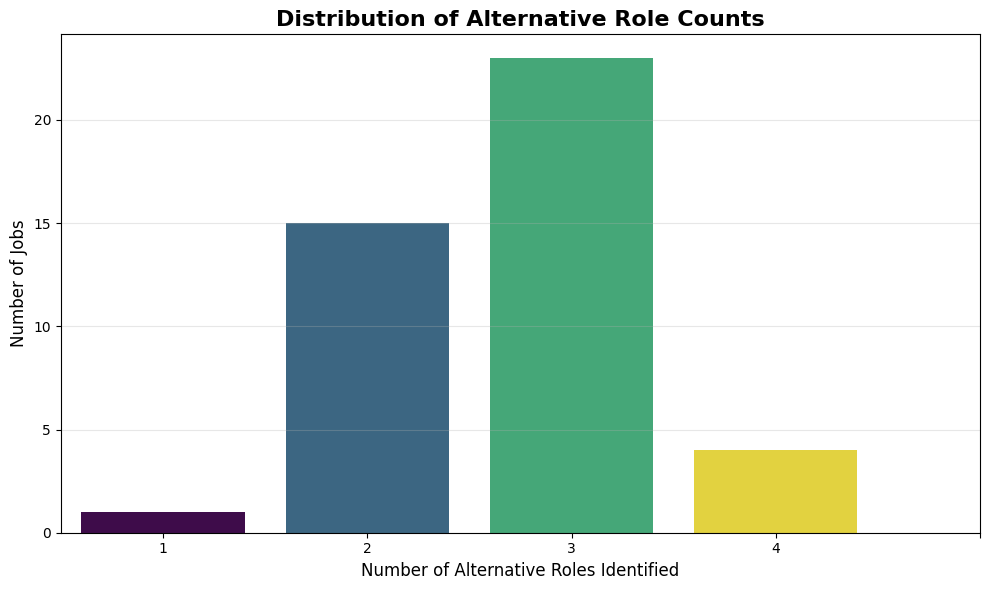

  ✅ Alternative distribution chart saved


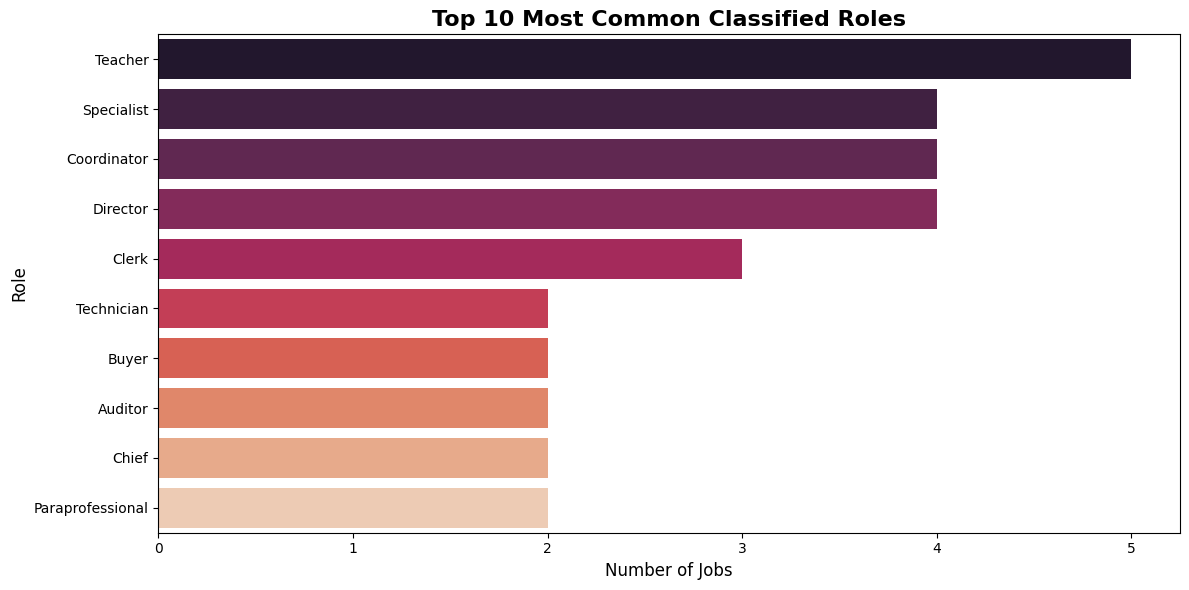

  ✅ Top roles chart saved


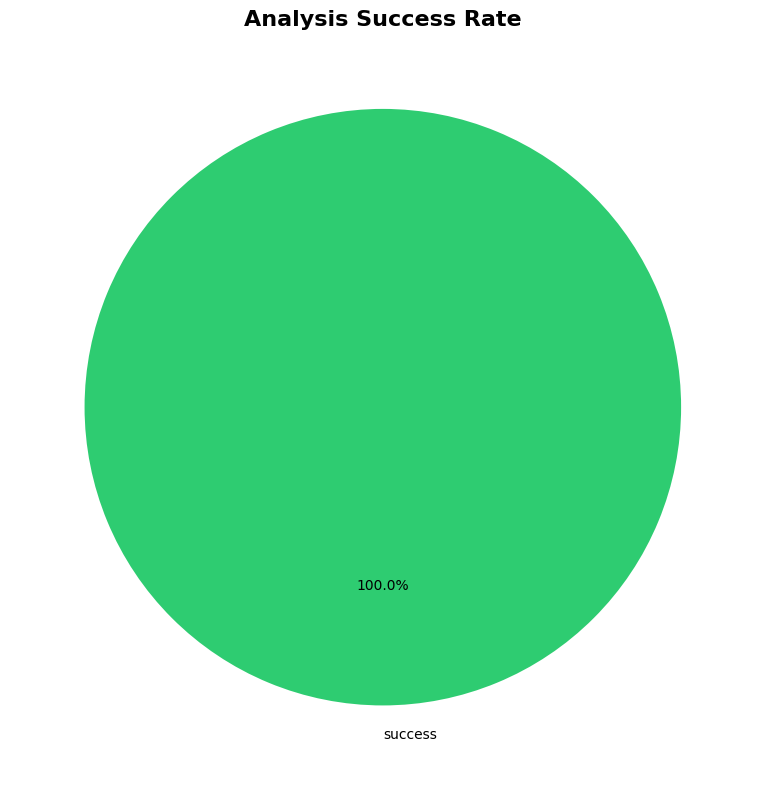

  ✅ Status breakdown chart saved



In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("📊 Generating visualizations...\n")

# =========================================================================
# 1. Distribution of Alternative Counts
# =========================================================================

df_results['alt_count'] = df_results['Primary Alternatives'].apply(
    lambda x: len([r.strip() for r in str(x).split(',') if r.strip()])
)

plt.figure(figsize=(10, 6))
sns.countplot(data=df_results, x='alt_count', palette='viridis', hue='alt_count', legend=False)
plt.title('Distribution of Alternative Role Counts', fontsize=16, fontweight='bold')
plt.xlabel('Number of Alternative Roles Identified', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.xticks(range(0, df_results['alt_count'].max() + 1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/alternative_distribution.png", dpi=300)
plt.show()

print("  ✅ Alternative distribution chart saved")

# =========================================================================
# 2. Top Classified Roles
# =========================================================================

plt.figure(figsize=(12, 6))
top_roles = df_results['Primary Role'].value_counts().head(10)
sns.barplot(x=top_roles.values, y=top_roles.index, palette='rocket', hue=top_roles.index, legend=False)
plt.title('Top 10 Most Common Classified Roles', fontsize=16, fontweight='bold')
plt.xlabel('Number of Jobs', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/top_roles.png", dpi=300)
plt.show()

print("  ✅ Top roles chart saved")

# =========================================================================
# 3. Analysis Status
# =========================================================================

plt.figure(figsize=(8, 8))
status_counts = df_results['Status'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
        colors=colors[:len(status_counts)], startangle=90)
plt.title('Analysis Success Rate', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/status_breakdown.png", dpi=300)
plt.show()

print("  ✅ Status breakdown chart saved\n")

## 8. Export Results

In [9]:
import shutil

# =========================================================================
# 💾 EXPORT RESULTS
# =========================================================================

# Save main results CSV
output_csv = f"{OUTPUT_PATH}/alternative_roles_analysis_{MODEL_MODE.lower()}.csv"
df_results.drop(columns=['Status', 'alt_count']).to_csv(output_csv, index=False)
print(f"✅ Results saved to: {output_csv}\n")

# Save summary statistics
summary = {
    'model_used': MODEL_MODE,
    'model_name': model_name,
    'total_jobs': total_jobs,
    'successful_analyses': int((df_results['Status'] == 'success').sum()),
    'success_rate': f"{success_rate:.1%}",
    'jobs_with_alternatives': int(jobs_with_alternatives),
    'percentage_with_alternatives': f"{jobs_with_alternatives/total_jobs:.1%}",
    'avg_alternatives_per_job': float(df_results['alt_count'].mean())
}

with open(f"{OUTPUT_PATH}/analysis_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

print("📊 Analysis Summary:")
print(json.dumps(summary, indent=2))
print()

# Create downloadable zip
print("📦 Creating download package...")
shutil.make_archive('/content/analysis_results', 'zip', OUTPUT_PATH)

try:
    files.download('/content/analysis_results.zip')
    print("✅ Download initiated!\n")
except:
    print(f"⚠️ Could not auto-download. Files saved to: {OUTPUT_PATH}\n")

print("="*70)
print("🎉 ANALYSIS PIPELINE COMPLETE!")
print("="*70)

✅ Results saved to: /content/analysis_results/alternative_roles_analysis_task_council.csv

📊 Analysis Summary:
{
  "model_used": "TASK_COUNCIL",
  "model_name": "claude-sonnet-4-5-20250929",
  "total_jobs": 43,
  "successful_analyses": 43,
  "success_rate": "100.0%",
  "jobs_with_alternatives": 43,
  "percentage_with_alternatives": "100.0%",
  "avg_alternatives_per_job": 2.697674418604651
}

📦 Creating download package...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download initiated!

🎉 ANALYSIS PIPELINE COMPLETE!
